In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from IPython.display import Audio, display
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np




In [26]:
def Retrieval_audio(name,quality):
    Metadata_path = "../dataset/metadata.json"
    if not os.path.exists(Metadata_path):    ## check if Metadata path exists or not
        print("Error : can not find audio")
        return 
    with open (Metadata_path,"r") as f :
        names = json.load(f)
        print("success load names")
    
    if name in names:
        audio_path = names[name]["paths"].get(quality)
        audio_data = names[name]

        if  os.path.exists(audio_path):
            print(f"play {name} with {quality} quality")
            display(Audio(filename=audio_path))
            print(json.dumps(audio_data, indent=4))
            return
        else :
            print("audio is not in folder")
    else :
        print("audio is not in Metadata.json")


def spectrogram(name, quality):
    Metadata_path = "../dataset/metadata.json"
    if not os.path.exists(Metadata_path):    ## check if Metadata path exists or not
        print("Error : can not find audio")
        return 
    with open (Metadata_path,"r") as f :
        names = json.load(f)
        print("success load names")
    audio_path = names[name]["paths"].get(quality)

    y, sr = librosa.load(audio_path, sr=None)
    D = librosa.stft(y, n_fft=2048, hop_length=512) ## window length and over lab tranh mat thong tin do vo tron nhu la hamming
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    plt.figure(figsize=(12, 5))
    librosa.display.specshow(S_db, sr=sr, hop_length=512,x_axis='time', y_axis='hz', cmap='magma')

    plt.colorbar(format='%+2.0f dB')
    plt.title("Spectrogram")
    plt.show()
    




success load names
play 146 with lossy quality


{
    "paths": {
        "original": "../dataset/original/146.wav",
        "lossless": "../dataset/lossless/146.flac",
        "lossy": "../dataset/lossy/146.mp3"
    },
    "sizes": {
        "size_original": "18.66 MB",
        "size_lossless": "12.48 MB",
        "size_lossy": "0.85 MB"
    },
    "info": {
        "sampe_rate": 44100,
        "channels": 2,
        "bit_depth_ori": "PCM_16",
        "bit_depth_lossless": "PCM_16",
        "bit_depth_lossy": "MPEG_LAYER_III"
    },
    "evaluation": {
        "lossless_compressrate": 1,
        "lossy_compressrate": 22,
        "bitrate_ori": 1411,
        "bitrate_losless": 944,
        "bitrate_lossy": 64,
        "lossless_snr": "Perfect (Inf)",
        "lossy_snr": 15
    }
}
success load names


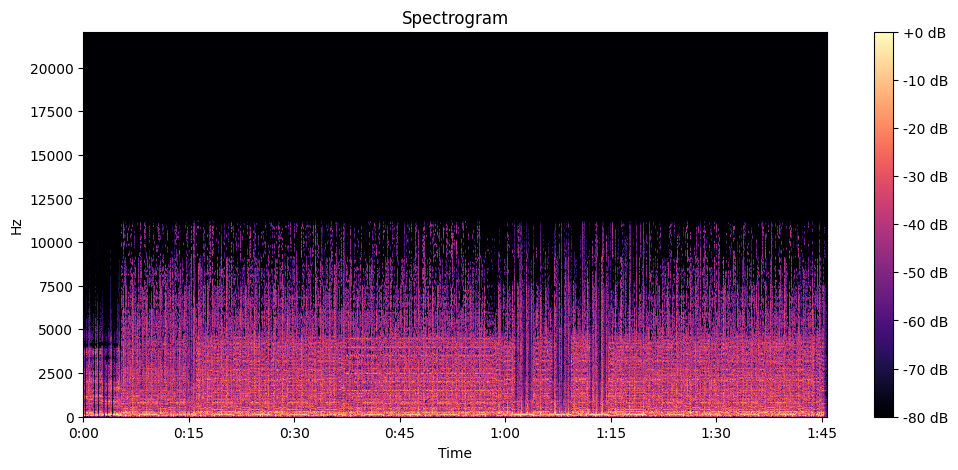

success load names


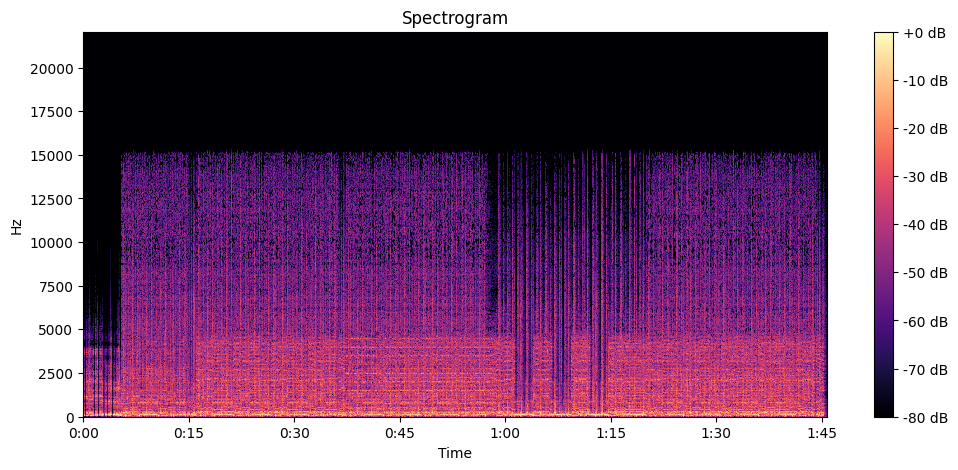

success load names


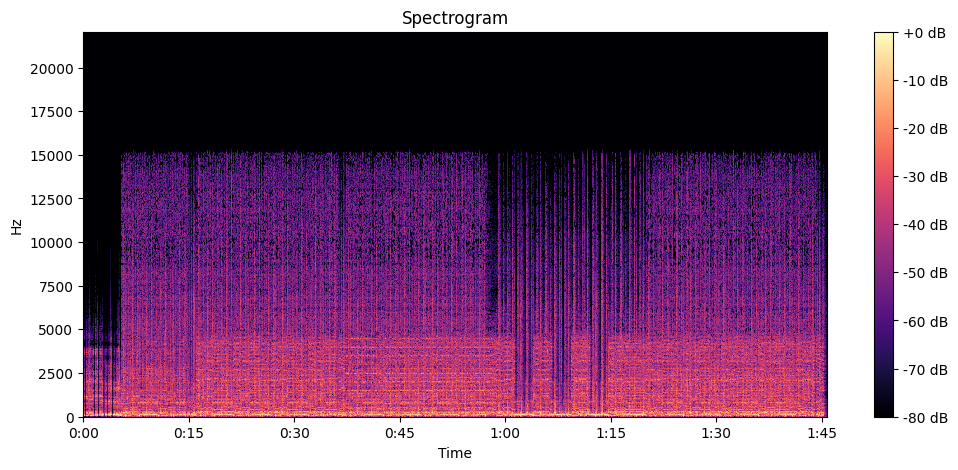

In [27]:
Retrieval_audio("146", "lossy")
spectrogram("146","lossy")
spectrogram("146","original")
spectrogram("146","lossless")




